# Proyecto Integrador - Equipo 16
## Avance 5: Modelo Final — Optimización y Comparativa de Modelos de Series de Tiempo

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

### Objetivo

Basándose en los resultados del **Avance 4**, donde los modelos de series de tiempo mostraron el mejor desempeño global, este notebook se enfoca en **optimizar exhaustivamente tres modelos de series de tiempo** para intentar mejorar las métricas obtenidas:

1. **SARIMAX** — Modelo ARIMA estacional con/sin variable exógena
2. **Prophet** — Modelo flexible de Meta con/sin regresor exógeno
3. **Holt-Winters** — Suavización exponencial con/sin variable exógena (enfoque híbrido con regresión)

Cada modelo se evalúa en **dos variantes**:
- **Sin variable exógena**: Solo la serie temporal de casos de sarampión
- **Con variable exógena**: Incorporando dosis de vacunación con desfase temporal

Esto produce **6 modelos** en total que se comparan con las métricas estándar:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **SMAPE** (Symmetric Mean Absolute Percentage Error)

### Estructura del Notebook
1. Configuración y carga de datos
2. Exploración de la estructura de `df_model`
3. Modelo 1-2: SARIMAX (sin y con exógena)
4. Modelo 3-4: Prophet (sin y con exógena)
5. Modelo 5-6: Holt-Winters (sin y con exógena)
6. Comparativa de los 6 modelos
7. Comparativa con Avance 4
8. Selección del modelo final
9. Conclusiones

---
## 1. Configuración del Ambiente y Librerías

In [98]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import product
from copy import deepcopy

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

# Configuración global
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# ── Constantes ──
SPLIT_YEAR = 2019
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023
DESFASE_VACUNAS = 3  # Meses de desfase para variable exógena

# ── Cache de hiperparámetros ──
FORZAR_GRID_SEARCH = False
CACHE_DIR = Path("cache_avance5")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (0-100%)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100.0 * np.mean(np.abs(y_true - y_pred) / denom))


def evaluar_metricas(y_true, y_pred):
    """Calcular MAE, RMSE y SMAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s = smape(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": float(rmse), "SMAPE(%)": float(s)}


print("✓ Librerías cargadas correctamente")
print(f"✓ Período de entrenamiento: {TRAIN_START_YEAR}-{TRAIN_END_YEAR}")
print(f"✓ Período de prueba: {TEST_START_YEAR}-{TEST_END_YEAR}")
print(f"✓ Desfase de vacunación: {DESFASE_VACUNAS} meses")
print(f"✓ Forzar grid search: {FORZAR_GRID_SEARCH}")
print(f"✓ Cache: {CACHE_DIR}")

✓ Librerías cargadas correctamente
✓ Período de entrenamiento: 2010-2018
✓ Período de prueba: 2019-2023
✓ Desfase de vacunación: 3 meses
✓ Forzar grid search: False
✓ Cache: cache_avance5


---
## 2. Carga de Datos y Construcción del Dataset

In [99]:
base_path = Path("..") / "data" / "processed"

# ── Dataset de Features Engineered ──
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# ── Dataset de Vacunación ──
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

# Variable binaria de brote
df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)

print(f"✓ df_fe cargado: {df_fe.shape}")
print(f"✓ df_vacunas cargado: {df_vacunas.shape}")
print(f"  Período df_fe: {df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()}")
print(f"  Período vacunas: {df_vacunas['fecha'].min().date()} → {df_vacunas['fecha'].max().date()}")

✓ df_fe cargado: (168, 27)
✓ df_vacunas cargado: (168, 5)
  Período df_fe: 2010-01-01 → 2023-12-01
  Período vacunas: 2010-01-01 → 2023-12-01


In [100]:
# ── Función de integración de vacunas con desfase ──
def integrar_vacunas_con_desfase(df_principal, df_vac, desfase_meses=0):
    df_vac_lag = df_vac.copy()
    df_vac_lag["fecha_join"] = df_vac_lag["fecha"] + pd.DateOffset(months=desfase_meses)
    col_name = f"total_dosis_lag_{desfase_meses}m"
    df_vac_lag = df_vac_lag[["fecha_join", "total_dosis"]].rename(
        columns={"total_dosis": col_name}
    )
    df_res = pd.merge(
        df_principal, df_vac_lag, left_on="fecha", right_on="fecha_join", how="left"
    )
    df_res.drop(columns=["fecha_join"], inplace=True)
    df_res.dropna(subset=[col_name], inplace=True)
    return df_res.reset_index(drop=True)


# ── Construir df_model ──
df_model = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=DESFASE_VACUNAS)

# Eliminar columnas PCA/FA (no útiles para series de tiempo)
pca_fa_cols = [c for c in df_model.columns if "pca" in c.lower() or "factor" in c.lower() or c.startswith("FA_")]
df_model.drop(columns=pca_fa_cols, inplace=True, errors="ignore")

# Filtrar período
df_model = df_model[
    (df_model["anio"] >= TRAIN_START_YEAR) & (df_model["anio"] <= TEST_END_YEAR)
].copy()

EXOG_COL = f"total_dosis_lag_{DESFASE_VACUNAS}m"

print(f"✓ df_model construido: {df_model.shape}")
print(f"✓ Período: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}")
print(f"✓ Variable exógena: {EXOG_COL}")
if pca_fa_cols:
    print(f"✓ Columnas PCA/FA eliminadas: {pca_fa_cols}")

✓ df_model construido: (165, 16)
✓ Período: 2010-04-01 → 2023-12-01
✓ Variable exógena: total_dosis_lag_3m
✓ Columnas PCA/FA eliminadas: ['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']


---
## 3. Estructura del DataFrame de Modelación (`df_model`)

In [101]:
print(f"{'='*80}")
print(f"  ESTRUCTURA DE df_model ({df_model.shape[0]} filas × {df_model.shape[1]} columnas)")
print(f"{'='*80}")

for i, col in enumerate(df_model.columns, 1):
    dtype = df_model[col].dtype
    n_null = df_model[col].isnull().sum()
    print(f"  {i:>2}. {col:<40s} | Tipo: {str(dtype):<15s} | Nulos: {n_null}")

print(f"\n{'─'*80}")
print("Estadísticas descriptivas de variables clave:")
display(df_model[["casos_sarampion", EXOG_COL]].describe().T)

  ESTRUCTURA DE df_model (165 filas × 16 columnas)
   1. fecha                                    | Tipo: datetime64[ns]  | Nulos: 0
   2. anio                                     | Tipo: int64           | Nulos: 0
   3. mes                                      | Tipo: int64           | Nulos: 0
   4. casos_sarampion                          | Tipo: int64           | Nulos: 0
   5. tasa_casos_por_millon_dosis              | Tipo: float64         | Nulos: 0
   6. casos_sarampion_log                      | Tipo: float64         | Nulos: 0
   7. casos_ytd_log                            | Tipo: float64         | Nulos: 0
   8. casos_rolling_mean_3m_log                | Tipo: float64         | Nulos: 0
   9. casos_rolling_mean_6m_log                | Tipo: float64         | Nulos: 0
  10. dosis_lag_14m_log                        | Tipo: float64         | Nulos: 0
  11. dosis_lag_13m_log                        | Tipo: float64         | Nulos: 0
  12. total_dosis_log                          

,count,mean,std,min,25%,50%,75%,max
casos_sarampion,165.0,2.303030,11.230090,0.0,0.0,0.0,0.0,81.0
total_dosis_lag_3m,165.0,315615.975758,359888.274166,11155.0,179330.0,228979.0,314388.0,3130610.0


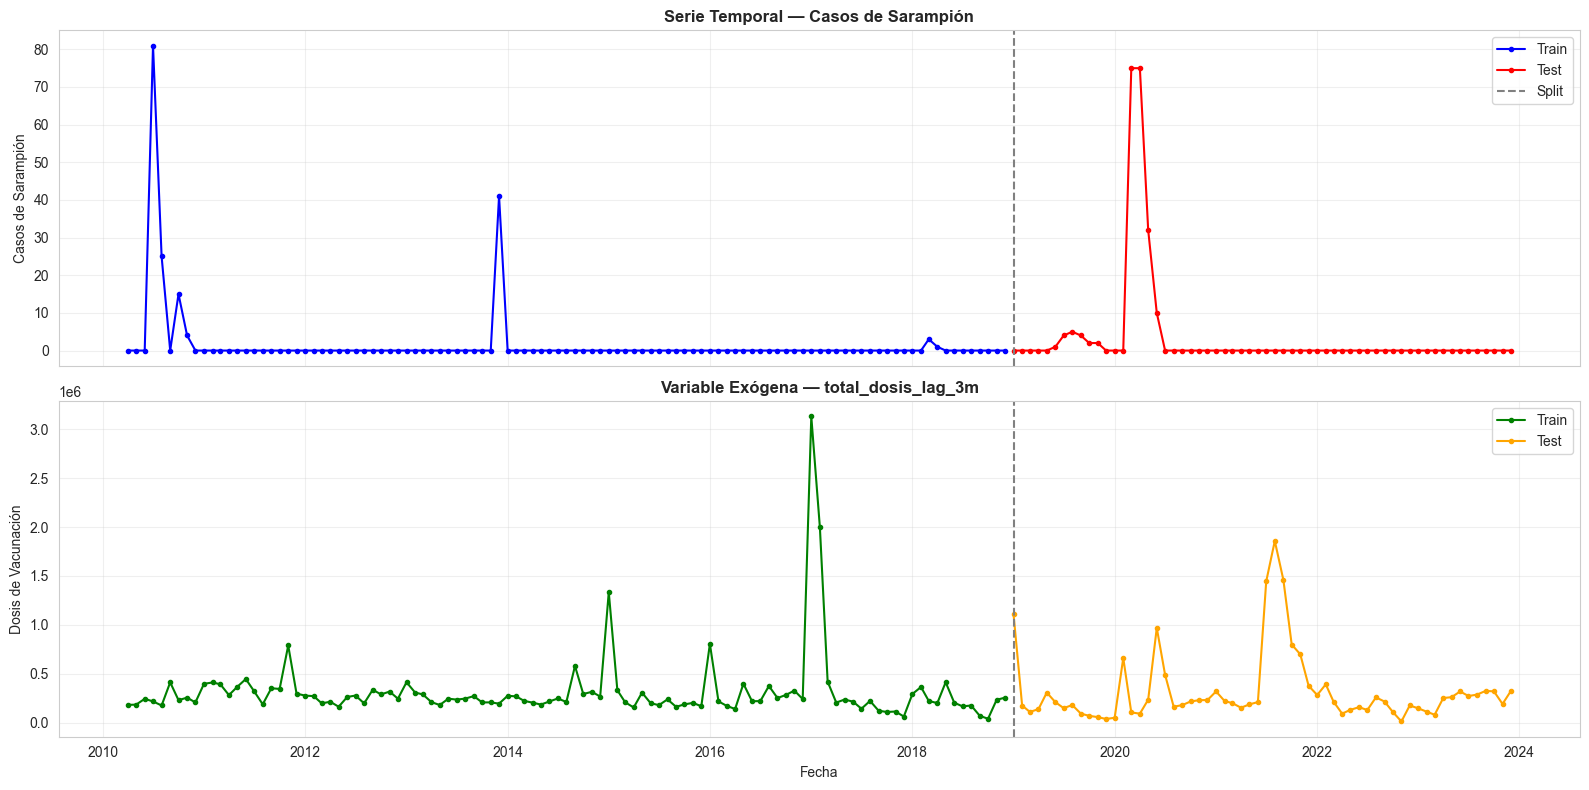


📊 Estadísticas clave:
   • Porcentaje de meses sin casos (ceros): 89.7%
   • Máximo de casos: 81
   • Media: 2.30


In [102]:
# ── Visualización de la serie y la variable exógena ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Serie de casos
train_mask = df_model["anio"] <= TRAIN_END_YEAR
test_mask = df_model["anio"] >= TEST_START_YEAR

axes[0].plot(df_model.loc[train_mask, "fecha"], df_model.loc[train_mask, "casos_sarampion"],
             "b-o", ms=3, lw=1.5, label="Train")
axes[0].plot(df_model.loc[test_mask, "fecha"], df_model.loc[test_mask, "casos_sarampion"],
             "r-o", ms=3, lw=1.5, label="Test")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5, label="Split")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("Serie Temporal — Casos de Sarampión", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variable exógena
axes[1].plot(df_model.loc[train_mask, "fecha"], df_model.loc[train_mask, EXOG_COL],
             "g-o", ms=3, lw=1.5, label="Train")
axes[1].plot(df_model.loc[test_mask, "fecha"], df_model.loc[test_mask, EXOG_COL],
             "orange", marker="o", ms=3, lw=1.5, label="Test")
axes[1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5)
axes[1].set_ylabel("Dosis de Vacunación")
axes[1].set_xlabel("Fecha")
axes[1].set_title(f"Variable Exógena — {EXOG_COL}", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas clave
pct_zeros = (df_model["casos_sarampion"] == 0).sum() / len(df_model) * 100
print(f"\n📊 Estadísticas clave:")
print(f"   • Porcentaje de meses sin casos (ceros): {pct_zeros:.1f}%")
print(f"   • Máximo de casos: {df_model['casos_sarampion'].max():.0f}")
print(f"   • Media: {df_model['casos_sarampion'].mean():.2f}")

---
## 4. Partición Temporal Train / Test

Separación cronológica estricta: **Train ≤ 2018** y **Test ≥ 2019**.

In [103]:
# ── Preparación de series para modelación ──
ts_train_mask = df_model["anio"] <= TRAIN_END_YEAR
ts_test_mask = df_model["anio"] >= TEST_START_YEAR

y_train = df_model.loc[ts_train_mask, "casos_sarampion"].astype(float).reset_index(drop=True)
y_test = df_model.loc[ts_test_mask, "casos_sarampion"].astype(float).reset_index(drop=True)

dates_train = df_model.loc[ts_train_mask, "fecha"].reset_index(drop=True)
dates_test = df_model.loc[ts_test_mask, "fecha"].reset_index(drop=True)

exog_train = df_model.loc[ts_train_mask, [EXOG_COL]].reset_index(drop=True).astype(float)
exog_test = df_model.loc[ts_test_mask, [EXOG_COL]].reset_index(drop=True).astype(float)

# Escalado de la exógena (solo con estadísticos del train)
exog_mean = exog_train.mean()
exog_std = exog_train.std().replace(0, 1.0)
exog_train_sc = (exog_train - exog_mean) / exog_std
exog_test_sc = (exog_test - exog_mean) / exog_std

print(f"✓ Train: {y_train.shape[0]} obs ({dates_train.min().date()} → {dates_train.max().date()})")
print(f"✓ Test:  {y_test.shape[0]} obs ({dates_test.min().date()} → {dates_test.max().date()})")
print(f"✓ Variable exógena: {EXOG_COL}")
print(f"  Train — media: {exog_train[EXOG_COL].mean():.2f}, std: {exog_train[EXOG_COL].std():.2f}")
print(f"  Test  — media: {exog_test[EXOG_COL].mean():.2f}, std: {exog_test[EXOG_COL].std():.2f}")

# Diccionario para recopilar resultados de todos los modelos
resultados_modelos = []
predicciones_modelos = {}

✓ Train: 105 obs (2010-04-01 → 2018-12-01)
✓ Test:  60 obs (2019-01-01 → 2023-12-01)
✓ Variable exógena: total_dosis_lag_3m
  Train — media: 313191.13, std: 360111.56
  Test  — media: 319859.45, std: 362495.05


---
## 5. Modelo 1: SARIMAX sin Variable Exógena

Se realiza una búsqueda exhaustiva de hiperparámetros para SARIMAX **sin variable exógena** (solo la serie temporal). Se evalúa con TimeSeriesSplit (5 folds, ventana=12 meses).

In [104]:
# ── Grid de búsqueda SARIMAX ──
p_range = [0, 1, 2]
d_range = [0, 1]
q_range = [0, 1, 2]
P_range = [0, 1]
D_range = [0, 1]
Q_range = [0, 1]
S = 12

sarimax_combinations = list(product(p_range, d_range, q_range, P_range, D_range, Q_range))
N_SPLITS_SARIMAX = 5
TEST_SIZE_SARIMAX = 12

print(f"Total de combinaciones SARIMAX: {len(sarimax_combinations)}")
print(f"Validación: TimeSeriesSplit con {N_SPLITS_SARIMAX} folds, ventana = {TEST_SIZE_SARIMAX} meses")

Total de combinaciones SARIMAX: 144
Validación: TimeSeriesSplit con 5 folds, ventana = 12 meses


In [105]:
# ── SARIMAX sin exógena — Grid Search ──
CACHE_SARIMAX_NO_EXOG = CACHE_DIR / "sarimax_no_exog_best.json"

if CACHE_SARIMAX_NO_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_SARIMAX_NO_EXOG, "r") as f:
        cache = json.load(f)
    best_sarimax_no_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_SARIMAX_NO_EXOG}")
    print(f"  order: {cache['order']}, seasonal: {cache['seasonal_order']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva SARIMAX sin exógena...\n")
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_SARIMAX, test_size=TEST_SIZE_SARIMAX)
    y_arr = y_train.values

    results_grid = []
    total = len(sarimax_combinations)

    for idx, (p, d, q, P, D, Q) in enumerate(sarimax_combinations):
        order = (p, d, q)
        seasonal_order = (P, D, Q, S)
        fold_rmses, fold_maes, fold_smapes = [], [], []
        success = True

        for train_idx, val_idx in tscv.split(y_arr):
            try:
                model = SARIMAX(
                    y_arr[train_idx], order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False,
                ).fit(disp=False, maxiter=300)
                preds = np.clip(model.forecast(steps=len(val_idx)), 0, None)
                fold_rmses.append(np.sqrt(mean_squared_error(y_arr[val_idx], preds)))
                fold_maes.append(mean_absolute_error(y_arr[val_idx], preds))
                fold_smapes.append(smape(y_arr[val_idx], preds))
            except Exception:
                success = False
                break

        if success and len(fold_rmses) == N_SPLITS_SARIMAX:
            results_grid.append({
                "order": order, "seasonal_order": seasonal_order,
                "mean_rmse_cv": np.mean(fold_rmses), "std_rmse_cv": np.std(fold_rmses),
                "mean_mae_cv": np.mean(fold_maes), "mean_smape_cv": np.mean(fold_smapes),
            })

        if (idx + 1) % 20 == 0 or idx == total - 1:
            print(f"  Progreso: {idx+1}/{total} | {len(results_grid)} exitosas")

    df_grid = pd.DataFrame(results_grid)
    df_grid["rank_rmse"] = df_grid["mean_rmse_cv"].rank()
    df_grid["rank_mae"] = df_grid["mean_mae_cv"].rank()
    df_grid["rank_smape"] = df_grid["mean_smape_cv"].rank()
    df_grid["composite_score"] = (df_grid["rank_rmse"] + df_grid["rank_mae"] + df_grid["rank_smape"]) / 3
    df_grid = df_grid.sort_values("composite_score").reset_index(drop=True)

    best = df_grid.iloc[0]
    best_sarimax_no_exog = {
        "order": list(best["order"]), "seasonal_order": list(best["seasonal_order"]),
        "rmse_cv": float(best["mean_rmse_cv"]), "mae_cv": float(best["mean_mae_cv"]),
        "smape_cv": float(best["mean_smape_cv"]),
    }

    with open(CACHE_SARIMAX_NO_EXOG, "w") as f:
        json.dump(best_sarimax_no_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada: {len(results_grid)} configuraciones válidas")
    print(f"★ Mejor: order={best['order']}, seasonal={best['seasonal_order']}")
    print(f"  RMSE_CV: {best['mean_rmse_cv']:.4f}, MAE_CV: {best['mean_mae_cv']:.4f}, SMAPE_CV: {best['mean_smape_cv']:.2f}%")
    print(f"✓ Guardado en {CACHE_SARIMAX_NO_EXOG}")

    print(f"\nTop 10 configuraciones:")
    display(df_grid.head(10)[["order", "seasonal_order", "mean_rmse_cv", "mean_mae_cv", "mean_smape_cv", "composite_score"]])

✓ Cargado desde cache: cache_avance5\sarimax_no_exog_best.json
  order: [0, 0, 0], seasonal: [0, 0, 0, 12]
  RMSE_CV: 0.1826


In [106]:
# ── Entrenar modelo SARIMAX sin exógena y evaluar en test ──
order_no_exog = tuple(best_sarimax_no_exog["order"])
seasonal_no_exog = tuple(best_sarimax_no_exog["seasonal_order"])

print(f"Entrenando SARIMAX{order_no_exog}×{seasonal_no_exog} (sin exógena)...")

model_sarimax_no_exog = SARIMAX(
    y_train, order=order_no_exog, seasonal_order=seasonal_no_exog,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

# Rolling 1-step-ahead
n_train = len(y_train)
y_test_reindexed = y_test.copy()
y_test_reindexed.index = range(n_train, n_train + len(y_test))

rolling_preds = []
current_model = model_sarimax_no_exog
for i in range(len(y_test)):
    fc = current_model.forecast(steps=1)
    rolling_preds.append(np.clip(fc.values[0], 0, None))
    if i < len(y_test) - 1:
        current_model = current_model.append(y_test_reindexed.iloc[[i]], refit=False)

forecast_sarimax_no_exog = np.array(rolling_preds)

metrics = evaluar_metricas(y_test, forecast_sarimax_no_exog)
resultados_modelos.append({
    "Modelo": f"SARIMAX {order_no_exog}×{seasonal_no_exog}",
    "Exógena": "No",
    **metrics,
})
predicciones_modelos["SARIMAX (sin exog)"] = forecast_sarimax_no_exog

print(f"\n✓ SARIMAX sin exógena — Resultados Test (rolling 1-step):")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

Entrenando SARIMAX(0, 0, 0)×(0, 0, 0, 12) (sin exógena)...

✓ SARIMAX sin exógena — Resultados Test (rolling 1-step):
  MAE:      3.5000
  RMSE:     14.3991
  SMAPE(%): 16.67%


---
## 6. Modelo 2: SARIMAX con Variable Exógena

Se repite la búsqueda exhaustiva de hiperparámetros, pero ahora incluyendo la variable exógena `total_dosis_lag_2m` (dosis de vacunación con desfase de 2 meses, escalada).

In [107]:
# ── SARIMAX con exógena — Grid Search ──
CACHE_SARIMAX_EXOG = CACHE_DIR / "sarimax_exog_best.json"

if CACHE_SARIMAX_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_SARIMAX_EXOG, "r") as f:
        cache = json.load(f)
    best_sarimax_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_SARIMAX_EXOG}")
    print(f"  order: {cache['order']}, seasonal: {cache['seasonal_order']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva SARIMAX con exógena...\n")
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_SARIMAX, test_size=TEST_SIZE_SARIMAX)
    y_arr = y_train.values
    exog_arr = exog_train_sc.values

    results_grid = []
    total = len(sarimax_combinations)

    for idx, (p, d, q, P, D, Q) in enumerate(sarimax_combinations):
        order = (p, d, q)
        seasonal_order = (P, D, Q, S)
        fold_rmses, fold_maes, fold_smapes = [], [], []
        success = True

        for train_idx, val_idx in tscv.split(y_arr):
            try:
                model = SARIMAX(
                    y_arr[train_idx], exog=exog_arr[train_idx],
                    order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False,
                ).fit(disp=False, maxiter=300)
                preds = np.clip(model.forecast(steps=len(val_idx), exog=exog_arr[val_idx]), 0, None)
                fold_rmses.append(np.sqrt(mean_squared_error(y_arr[val_idx], preds)))
                fold_maes.append(mean_absolute_error(y_arr[val_idx], preds))
                fold_smapes.append(smape(y_arr[val_idx], preds))
            except Exception:
                success = False
                break

        if success and len(fold_rmses) == N_SPLITS_SARIMAX:
            results_grid.append({
                "order": order, "seasonal_order": seasonal_order,
                "mean_rmse_cv": np.mean(fold_rmses), "std_rmse_cv": np.std(fold_rmses),
                "mean_mae_cv": np.mean(fold_maes), "mean_smape_cv": np.mean(fold_smapes),
            })

        if (idx + 1) % 20 == 0 or idx == total - 1:
            print(f"  Progreso: {idx+1}/{total} | {len(results_grid)} exitosas")

    df_grid = pd.DataFrame(results_grid)
    df_grid["rank_rmse"] = df_grid["mean_rmse_cv"].rank()
    df_grid["rank_mae"] = df_grid["mean_mae_cv"].rank()
    df_grid["rank_smape"] = df_grid["mean_smape_cv"].rank()
    df_grid["composite_score"] = (df_grid["rank_rmse"] + df_grid["rank_mae"] + df_grid["rank_smape"]) / 3
    df_grid = df_grid.sort_values("composite_score").reset_index(drop=True)

    best = df_grid.iloc[0]
    best_sarimax_exog = {
        "order": list(best["order"]), "seasonal_order": list(best["seasonal_order"]),
        "rmse_cv": float(best["mean_rmse_cv"]), "mae_cv": float(best["mean_mae_cv"]),
        "smape_cv": float(best["mean_smape_cv"]),
    }

    with open(CACHE_SARIMAX_EXOG, "w") as f:
        json.dump(best_sarimax_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada: {len(results_grid)} configuraciones válidas")
    print(f"★ Mejor: order={best['order']}, seasonal={best['seasonal_order']}")
    print(f"  RMSE_CV: {best['mean_rmse_cv']:.4f}, MAE_CV: {best['mean_mae_cv']:.4f}, SMAPE_CV: {best['mean_smape_cv']:.2f}%")
    print(f"✓ Guardado en {CACHE_SARIMAX_EXOG}")

    print(f"\nTop 10 configuraciones:")
    display(df_grid.head(10)[["order", "seasonal_order", "mean_rmse_cv", "mean_mae_cv", "mean_smape_cv", "composite_score"]])

✓ Cargado desde cache: cache_avance5\sarimax_exog_best.json
  order: [2, 0, 2], seasonal: [0, 0, 1, 12]
  RMSE_CV: 0.6509


In [108]:
# ── Entrenar modelo SARIMAX con exógena y evaluar en test ──
order_exog = tuple(best_sarimax_exog["order"])
seasonal_exog = tuple(best_sarimax_exog["seasonal_order"])

print(f"Entrenando SARIMAX{order_exog}×{seasonal_exog} (con exógena: {EXOG_COL})...")

model_sarimax_exog = SARIMAX(
    y_train, exog=exog_train_sc, order=order_exog, seasonal_order=seasonal_exog,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

# Rolling 1-step-ahead con exógena
exog_test_reindexed = exog_test_sc.copy()
exog_test_reindexed.index = range(n_train, n_train + len(y_test))

rolling_preds = []
current_model = model_sarimax_exog
for i in range(len(y_test)):
    fc = current_model.forecast(steps=1, exog=exog_test_reindexed.iloc[[i]])
    rolling_preds.append(np.clip(fc.values[0], 0, None))
    if i < len(y_test) - 1:
        current_model = current_model.append(
            y_test_reindexed.iloc[[i]], exog=exog_test_reindexed.iloc[[i]], refit=False
        )

forecast_sarimax_exog = np.array(rolling_preds)

metrics = evaluar_metricas(y_test, forecast_sarimax_exog)
resultados_modelos.append({
    "Modelo": f"SARIMAX {order_exog}×{seasonal_exog}",
    "Exógena": "Sí",
    **metrics,
})
predicciones_modelos["SARIMAX (con exog)"] = forecast_sarimax_exog

print(f"\n✓ SARIMAX con exógena — Resultados Test (rolling 1-step):")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

Entrenando SARIMAX(2, 0, 2)×(0, 0, 1, 12) (con exógena: total_dosis_lag_3m)...

✓ SARIMAX con exógena — Resultados Test (rolling 1-step):
  MAE:      3.5178
  RMSE:     14.3774
  SMAPE(%): 72.72%


---
## 7. Modelo 3: Prophet sin Variable Exógena

Se optimiza Prophet mediante grid search exhaustivo de hiperparámetros, **sin incluir vacunación como regresor**. Se evalúa con TimeSeriesSplit (4 folds).

In [109]:
# ── Preparar datasets para Prophet ──
df_prophet_train = pd.DataFrame({
    "ds": dates_train.values,
    "y": y_train.values,
    "vacunas": exog_train_sc[EXOG_COL].values,
})
df_prophet_test = pd.DataFrame({
    "ds": dates_test.values,
    "y": y_test.values,
    "vacunas": exog_test_sc[EXOG_COL].values,
})

# ── Grid de hiperparámetros Prophet ──
param_grid_prophet = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "seasonality_prior_scale": [0.1, 1.0, 5.0, 10.0, 20.0],
    "seasonality_mode": ["additive", "multiplicative"],
    "yearly_seasonality": [True, False],
}
prophet_combinations = list(product(
    param_grid_prophet["changepoint_prior_scale"],
    param_grid_prophet["seasonality_prior_scale"],
    param_grid_prophet["seasonality_mode"],
    param_grid_prophet["yearly_seasonality"],
))

print(f"Total de combinaciones Prophet: {len(prophet_combinations)}")
print(f"Validación: TimeSeriesSplit con 4 folds")

Total de combinaciones Prophet: 120
Validación: TimeSeriesSplit con 4 folds


In [110]:
# ── Función de CV temporal para Prophet ──
def cv_prophet(df_train, params, use_exog=False, n_splits=4):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []
    for train_idx, val_idx in tscv.split(df_train):
        train_fold = df_train.iloc[train_idx].copy()
        val_fold = df_train.iloc[val_idx].copy()
        try:
            model = Prophet(
                changepoint_prior_scale=params["changepoint_prior_scale"],
                seasonality_prior_scale=params["seasonality_prior_scale"],
                seasonality_mode=params["seasonality_mode"],
                yearly_seasonality=params["yearly_seasonality"],
                weekly_seasonality=False,
                daily_seasonality=False,
            )
            if use_exog:
                model.add_regressor("vacunas")
            model.fit(train_fold[["ds", "y"] + (["vacunas"] if use_exog else [])])
            predict_cols = ["ds"] + (["vacunas"] if use_exog else [])
            forecast = model.predict(val_fold[predict_cols])
            y_pred = np.clip(forecast["yhat"].values, 0, None)
            rmses.append(np.sqrt(mean_squared_error(val_fold["y"].values, y_pred)))
        except Exception:
            pass
    return np.mean(rmses) if rmses else np.inf

print("✓ Función de validación temporal para Prophet definida")

✓ Función de validación temporal para Prophet definida


In [111]:
# ── Prophet sin exógena — Grid Search ──
CACHE_PROPHET_NO_EXOG = CACHE_DIR / "prophet_no_exog_best.json"

if CACHE_PROPHET_NO_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_PROPHET_NO_EXOG, "r") as f:
        cache = json.load(f)
    best_prophet_no_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_PROPHET_NO_EXOG}")
    print(f"  Params: {cache['params']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva Prophet sin exógena...\n")

    best_prophet_no_exog = {"rmse_cv": np.inf, "params": None}
    results_prophet = []

    for idx, (cps, sps, mode, yearly) in enumerate(prophet_combinations, 1):
        params = {
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "seasonality_mode": mode,
            "yearly_seasonality": yearly,
        }
        rmse_cv = cv_prophet(df_prophet_train, params, use_exog=False)
        results_prophet.append({**params, "rmse_cv": rmse_cv})

        if rmse_cv < best_prophet_no_exog["rmse_cv"]:
            best_prophet_no_exog = {"params": params, "rmse_cv": rmse_cv}

        if idx % 20 == 0:
            print(f"  Progreso: {idx}/{len(prophet_combinations)} | Mejor RMSE_CV: {best_prophet_no_exog['rmse_cv']:.4f}")

    with open(CACHE_PROPHET_NO_EXOG, "w") as f:
        json.dump(best_prophet_no_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada")
    print(f"★ Mejor: {best_prophet_no_exog['params']}")
    print(f"  RMSE_CV: {best_prophet_no_exog['rmse_cv']:.4f}")
    print(f"✓ Guardado en {CACHE_PROPHET_NO_EXOG}")

    df_pr = pd.DataFrame(results_prophet)
    df_pr = df_pr[df_pr["rmse_cv"] != np.inf].sort_values("rmse_cv")
    print(f"\nTop 10 configuraciones:")
    display(df_pr.head(10))

✓ Cargado desde cache: cache_avance5\prophet_no_exog_best.json
  Params: {'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True}
  RMSE_CV: 2.6023


In [112]:
# ── Entrenar Prophet sin exógena y evaluar en test ──
bp = best_prophet_no_exog["params"]
print(f"Entrenando Prophet sin exógena con: {bp}")

modelo_prophet_no_exog = Prophet(
    changepoint_prior_scale=bp["changepoint_prior_scale"],
    seasonality_prior_scale=bp["seasonality_prior_scale"],
    seasonality_mode=bp["seasonality_mode"],
    yearly_seasonality=bp["yearly_seasonality"],
    weekly_seasonality=False, daily_seasonality=False,
)
modelo_prophet_no_exog.fit(df_prophet_train[["ds", "y"]])

forecast = modelo_prophet_no_exog.predict(df_prophet_test[["ds"]])
forecast_prophet_no_exog = np.clip(forecast["yhat"].values, 0, None)

metrics = evaluar_metricas(y_test, forecast_prophet_no_exog)
resultados_modelos.append({
    "Modelo": f"Prophet",
    "Exógena": "No",
    **metrics,
})
predicciones_modelos["Prophet (sin exog)"] = forecast_prophet_no_exog

print(f"\n✓ Prophet sin exógena — Resultados Test:")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

21:37:23 - cmdstanpy - INFO - Chain [1] start processing


Entrenando Prophet sin exógena con: {'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True}


21:37:23 - cmdstanpy - INFO - Chain [1] done processing



✓ Prophet sin exógena — Resultados Test:
  MAE:      3.6837
  RMSE:     14.3741
  SMAPE(%): 97.71%


---
## 8. Modelo 4: Prophet con Variable Exógena

Se repite la optimización de Prophet, ahora incluyendo `vacunas` (dosis con desfase, escalada) como regresor exógeno.

In [113]:
# ── Prophet con exógena — Grid Search ──
CACHE_PROPHET_EXOG = CACHE_DIR / "prophet_exog_best.json"

if CACHE_PROPHET_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_PROPHET_EXOG, "r") as f:
        cache = json.load(f)
    best_prophet_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_PROPHET_EXOG}")
    print(f"  Params: {cache['params']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva Prophet con exógena...\n")

    best_prophet_exog = {"rmse_cv": np.inf, "params": None}
    results_prophet = []

    for idx, (cps, sps, mode, yearly) in enumerate(prophet_combinations, 1):
        params = {
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "seasonality_mode": mode,
            "yearly_seasonality": yearly,
        }
        rmse_cv = cv_prophet(df_prophet_train, params, use_exog=True)
        results_prophet.append({**params, "rmse_cv": rmse_cv})

        if rmse_cv < best_prophet_exog["rmse_cv"]:
            best_prophet_exog = {"params": params, "rmse_cv": rmse_cv}

        if idx % 20 == 0:
            print(f"  Progreso: {idx}/{len(prophet_combinations)} | Mejor RMSE_CV: {best_prophet_exog['rmse_cv']:.4f}")

    with open(CACHE_PROPHET_EXOG, "w") as f:
        json.dump(best_prophet_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada")
    print(f"★ Mejor: {best_prophet_exog['params']}")
    print(f"  RMSE_CV: {best_prophet_exog['rmse_cv']:.4f}")
    print(f"✓ Guardado en {CACHE_PROPHET_EXOG}")

    df_pr = pd.DataFrame(results_prophet)
    df_pr = df_pr[df_pr["rmse_cv"] != np.inf].sort_values("rmse_cv")
    print(f"\nTop 10 configuraciones:")
    display(df_pr.head(10))

✓ Cargado desde cache: cache_avance5\prophet_exog_best.json
  Params: {'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True}
  RMSE_CV: 2.6285


In [114]:
# ── Entrenar Prophet con exógena y evaluar en test ──
bp = best_prophet_exog["params"]
print(f"Entrenando Prophet con exógena con: {bp}")

modelo_prophet_exog = Prophet(
    changepoint_prior_scale=bp["changepoint_prior_scale"],
    seasonality_prior_scale=bp["seasonality_prior_scale"],
    seasonality_mode=bp["seasonality_mode"],
    yearly_seasonality=bp["yearly_seasonality"],
    weekly_seasonality=False, daily_seasonality=False,
)
modelo_prophet_exog.add_regressor("vacunas")
modelo_prophet_exog.fit(df_prophet_train[["ds", "y", "vacunas"]])

forecast = modelo_prophet_exog.predict(df_prophet_test[["ds", "vacunas"]])
forecast_prophet_exog = np.clip(forecast["yhat"].values, 0, None)

metrics = evaluar_metricas(y_test, forecast_prophet_exog)
resultados_modelos.append({
    "Modelo": f"Prophet",
    "Exógena": "Sí",
    **metrics,
})
predicciones_modelos["Prophet (con exog)"] = forecast_prophet_exog

print(f"\n✓ Prophet con exógena — Resultados Test:")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

21:37:23 - cmdstanpy - INFO - Chain [1] start processing


Entrenando Prophet con exógena con: {'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True}


21:37:23 - cmdstanpy - INFO - Chain [1] done processing



✓ Prophet con exógena — Resultados Test:
  MAE:      3.5008
  RMSE:     14.3983
  SMAPE(%): 43.33%


---
## 9. Modelo 5: Holt-Winters sin Variable Exógena

Holt-Winters (ExponentialSmoothing) modela tendencia y estacionalidad directamente. Se optimizan los hiperparámetros de suavización ($\alpha$, $\beta$, $\gamma$), tipo de tendencia y estacionalidad.

In [115]:
# ── Grid de hiperparámetros Holt-Winters ──
hw_param_grid = {
    "alpha": [0.2, 0.4, 0.6, 0.8],
    "beta": [0.0, 0.1, 0.2],
    "gamma": [0.0, 0.1, 0.2],
    "trend": [None, "add"],
    "damped_trend": [False, True],
    "seasonal": [None, "add"],
    "seasonal_periods": [12],
}

hw_grid = []
for a, b, g, t, d, s, sp in product(
    hw_param_grid["alpha"], hw_param_grid["beta"], hw_param_grid["gamma"],
    hw_param_grid["trend"], hw_param_grid["damped_trend"],
    hw_param_grid["seasonal"], hw_param_grid["seasonal_periods"],
):
    params = {
        "alpha": a,
        "beta": None if t is None else b,
        "gamma": None if s is None else g,
        "trend": t,
        "damped_trend": False if t is None else d,
        "seasonal": s,
        "seasonal_periods": None if s is None else sp,
    }
    hw_grid.append(params)

print(f"Total de combinaciones Holt-Winters: {len(hw_grid)}")

Total de combinaciones Holt-Winters: 288


In [116]:
# ── Funciones de evaluación Holt-Winters ──

def hw_fit_forecast_no_exog(y_train_arr, h, params):
    """Ajustar Holt-Winters sin exógena y generar forecast."""
    model = ExponentialSmoothing(
        y_train_arr,
        trend=params["trend"],
        damped_trend=params["damped_trend"],
        seasonal=params["seasonal"],
        seasonal_periods=params["seasonal_periods"],
        initialization_method="estimated",
    )
    fit = model.fit(
        smoothing_level=params["alpha"],
        smoothing_trend=params["beta"],
        smoothing_seasonal=params["gamma"],
        optimized=False,
    )
    y_pred = np.clip(fit.forecast(h), 0, None)
    return y_pred, fit


def fit_regression_with_intercept(x, y):
    """Regresión lineal simple con intercepto."""
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1, 1)
    X = np.hstack([np.ones((len(x), 1)), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(beta[0, 0]), float(beta[1, 0])


def hw_exog_fit_forecast(y_train_arr, exog_train_arr, exog_future_arr, params):
    """Holt-Winters híbrido: regresión sobre exógena + ETS sobre residuos."""
    b0, b1 = fit_regression_with_intercept(exog_train_arr, y_train_arr)
    y_reg = b0 + b1 * exog_train_arr
    resid = y_train_arr - y_reg

    model = ExponentialSmoothing(
        resid,
        trend=params["trend"],
        damped_trend=params["damped_trend"],
        seasonal=params["seasonal"],
        seasonal_periods=params["seasonal_periods"],
        initialization_method="estimated",
    )
    fit = model.fit(
        smoothing_level=params["alpha"],
        smoothing_trend=params["beta"],
        smoothing_seasonal=params["gamma"],
        optimized=False,
    )

    h = len(exog_future_arr)
    resid_fore = fit.forecast(h)
    y_reg_future = b0 + b1 * exog_future_arr
    y_pred = np.clip(y_reg_future + resid_fore, 0, None)
    return y_pred, fit, b0, b1


def cv_hw(y_arr, exog_arr, params, use_exog=False, n_splits=4):
    """Validación temporal Holt-Winters."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []
    for train_idx, val_idx in tscv.split(y_arr):
        try:
            if use_exog:
                y_pred, *_ = hw_exog_fit_forecast(
                    y_arr[train_idx], exog_arr[train_idx], exog_arr[val_idx], params
                )
            else:
                y_pred, _ = hw_fit_forecast_no_exog(y_arr[train_idx], len(val_idx), params)
            rmses.append(np.sqrt(mean_squared_error(y_arr[val_idx], y_pred)))
        except Exception:
            pass
    return np.mean(rmses) if rmses else np.inf

print("✓ Funciones Holt-Winters definidas")

✓ Funciones Holt-Winters definidas


In [117]:
# ── Holt-Winters sin exógena — Grid Search ──
CACHE_HW_NO_EXOG = CACHE_DIR / "hw_no_exog_best.json"

if CACHE_HW_NO_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_HW_NO_EXOG, "r") as f:
        cache = json.load(f)
    best_hw_no_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_HW_NO_EXOG}")
    print(f"  Params: {cache['params']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva Holt-Winters sin exógena...\n")

    best_hw_no_exog = {"rmse_cv": np.inf, "params": None}
    y_arr = y_train.values

    for i, params in enumerate(hw_grid):
        rmse_cv = cv_hw(y_arr, None, params, use_exog=False)
        if rmse_cv < best_hw_no_exog["rmse_cv"]:
            best_hw_no_exog = {"params": params, "rmse_cv": float(rmse_cv)}

        if (i + 1) % 20 == 0:
            print(f"  Progreso: {i+1}/{len(hw_grid)} | Mejor RMSE_CV: {best_hw_no_exog['rmse_cv']:.4f}")

    with open(CACHE_HW_NO_EXOG, "w") as f:
        json.dump(best_hw_no_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada")
    print(f"★ Mejor: {best_hw_no_exog['params']}")
    print(f"  RMSE_CV: {best_hw_no_exog['rmse_cv']:.4f}")
    print(f"✓ Guardado en {CACHE_HW_NO_EXOG}")

✓ Cargado desde cache: cache_avance5\hw_no_exog_best.json
  Params: {'alpha': 0.4, 'beta': 0.2, 'gamma': 0.1, 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 12}
  RMSE_CV: 1.2752


In [118]:
# ── Entrenar Holt-Winters sin exógena y evaluar en test ──
hw_params = best_hw_no_exog["params"]
print(f"Entrenando Holt-Winters sin exógena con: {hw_params}")

forecast_hw_no_exog, fit_hw_no_exog = hw_fit_forecast_no_exog(
    y_train.values, len(y_test), hw_params
)

metrics = evaluar_metricas(y_test, forecast_hw_no_exog)
resultados_modelos.append({
    "Modelo": "Holt-Winters",
    "Exógena": "No",
    **metrics,
})
predicciones_modelos["Holt-Winters (sin exog)"] = forecast_hw_no_exog

print(f"\n✓ Holt-Winters sin exógena — Resultados Test:")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

Entrenando Holt-Winters sin exógena con: {'alpha': 0.4, 'beta': 0.2, 'gamma': 0.1, 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 12}

✓ Holt-Winters sin exógena — Resultados Test:
  MAE:      3.5000
  RMSE:     14.3991
  SMAPE(%): 16.67%


---
## 10. Modelo 6: Holt-Winters con Variable Exógena

Se utiliza el enfoque **híbrido**: regresión lineal sobre la variable exógena + Holt-Winters sobre los residuos. Esto permite incorporar vacunación indirectamente.

In [119]:
# ── Holt-Winters con exógena — Grid Search ──
CACHE_HW_EXOG = CACHE_DIR / "hw_exog_best.json"

if CACHE_HW_EXOG.exists() and not FORZAR_GRID_SEARCH:
    with open(CACHE_HW_EXOG, "r") as f:
        cache = json.load(f)
    best_hw_exog = cache
    print(f"✓ Cargado desde cache: {CACHE_HW_EXOG}")
    print(f"  Params: {cache['params']}")
    print(f"  RMSE_CV: {cache['rmse_cv']:.4f}")
else:
    print("Iniciando búsqueda exhaustiva Holt-Winters con exógena...\n")

    best_hw_exog = {"rmse_cv": np.inf, "params": None}
    y_arr = y_train.values
    exog_arr = exog_train_sc[EXOG_COL].values

    for i, params in enumerate(hw_grid):
        rmse_cv = cv_hw(y_arr, exog_arr, params, use_exog=True)
        if rmse_cv < best_hw_exog["rmse_cv"]:
            best_hw_exog = {"params": params, "rmse_cv": float(rmse_cv)}

        if (i + 1) % 20 == 0:
            print(f"  Progreso: {i+1}/{len(hw_grid)} | Mejor RMSE_CV: {best_hw_exog['rmse_cv']:.4f}")

    with open(CACHE_HW_EXOG, "w") as f:
        json.dump(best_hw_exog, f, indent=2)

    print(f"\n✓ Búsqueda completada")
    print(f"★ Mejor: {best_hw_exog['params']}")
    print(f"  RMSE_CV: {best_hw_exog['rmse_cv']:.4f}")
    print(f"✓ Guardado en {CACHE_HW_EXOG}")

✓ Cargado desde cache: cache_avance5\hw_exog_best.json
  Params: {'alpha': 0.4, 'beta': 0.2, 'gamma': 0.1, 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 12}
  RMSE_CV: 1.2368


In [120]:
# ── Entrenar Holt-Winters con exógena y evaluar en test ──
hw_params = best_hw_exog["params"]
print(f"Entrenando Holt-Winters con exógena con: {hw_params}")

forecast_hw_exog, fit_hw_exog, b0_hw, b1_hw = hw_exog_fit_forecast(
    y_train.values,
    exog_train_sc[EXOG_COL].values,
    exog_test_sc[EXOG_COL].values,
    hw_params,
)

metrics = evaluar_metricas(y_test, forecast_hw_exog)
resultados_modelos.append({
    "Modelo": "Holt-Winters (híbrido)",
    "Exógena": "Sí",
    **metrics,
})
predicciones_modelos["Holt-Winters (con exog)"] = forecast_hw_exog

print(f"\n✓ Holt-Winters con exógena — Resultados Test:")
print(f"  MAE:      {metrics['MAE']:.4f}")
print(f"  RMSE:     {metrics['RMSE']:.4f}")
print(f"  SMAPE(%): {metrics['SMAPE(%)']:.2f}%")

Entrenando Holt-Winters con exógena con: {'alpha': 0.4, 'beta': 0.2, 'gamma': 0.1, 'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 12}

✓ Holt-Winters con exógena — Resultados Test:
  MAE:      3.5000
  RMSE:     14.3991
  SMAPE(%): 16.67%


---
## 11. Comparativa de los 6 Modelos Optimizados

Se consolidan los resultados de los 6 modelos (3 tipos × 2 variantes) y se selecciona el mejor basado en las métricas RMSE, MAE y SMAPE.

In [121]:
# ── Tabla comparativa de los 6 modelos ──
df_resultados = pd.DataFrame(resultados_modelos)

# Score compuesto (promedio de rangos normalizados)
df_resultados["rank_RMSE"] = df_resultados["RMSE"].rank()
df_resultados["rank_MAE"] = df_resultados["MAE"].rank()
df_resultados["rank_SMAPE"] = df_resultados["SMAPE(%)"].rank()
df_resultados["Score"] = (
    df_resultados["rank_RMSE"] + df_resultados["rank_MAE"] + df_resultados["rank_SMAPE"]
) / 3
df_resultados = df_resultados.sort_values("Score").reset_index(drop=True)

print("=" * 90)
print("  COMPARATIVA DE 6 MODELOS OPTIMIZADOS — AVANCE 5")
print("=" * 90)
display(df_resultados[["Modelo", "Exógena", "MAE", "RMSE", "SMAPE(%)", "Score"]])

# Identificar mejor modelo
best_model_row = df_resultados.iloc[0]
print(f"\n{'★' * 60}")
print(f"  MEJOR MODELO: {best_model_row['Modelo']} (Exógena: {best_model_row['Exógena']})")
print(f"{'★' * 60}")
print(f"  MAE:      {best_model_row['MAE']:.4f}")
print(f"  RMSE:     {best_model_row['RMSE']:.4f}")
print(f"  SMAPE(%): {best_model_row['SMAPE(%)']:.2f}%")
print(f"  Score compuesto: {best_model_row['Score']:.2f}")

  COMPARATIVA DE 6 MODELOS OPTIMIZADOS — AVANCE 5


,Modelo,Exógena,MAE,RMSE,SMAPE(%),Score
0,"SARIMAX (0, 0, 0)×(0, 0, 0, 12)",No,3.500000,14.399074,16.666667,3.000000
1,Holt-Winters,No,3.500000,14.399074,16.666667,3.000000
2,Holt-Winters (híbrido),Sí,3.500000,14.399074,16.666667,3.000000
3,Prophet,Sí,3.500802,14.398301,43.328194,3.666667
4,"SARIMAX (2, 0, 2)×(0, 0, 1, 12)",Sí,3.517770,14.377414,72.722374,4.000000
5,Prophet,No,3.683749,14.374106,97.710627,4.333333



★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  MEJOR MODELO: SARIMAX (0, 0, 0)×(0, 0, 0, 12) (Exógena: No)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  MAE:      3.5000
  RMSE:     14.3991
  SMAPE(%): 16.67%
  Score compuesto: 3.00


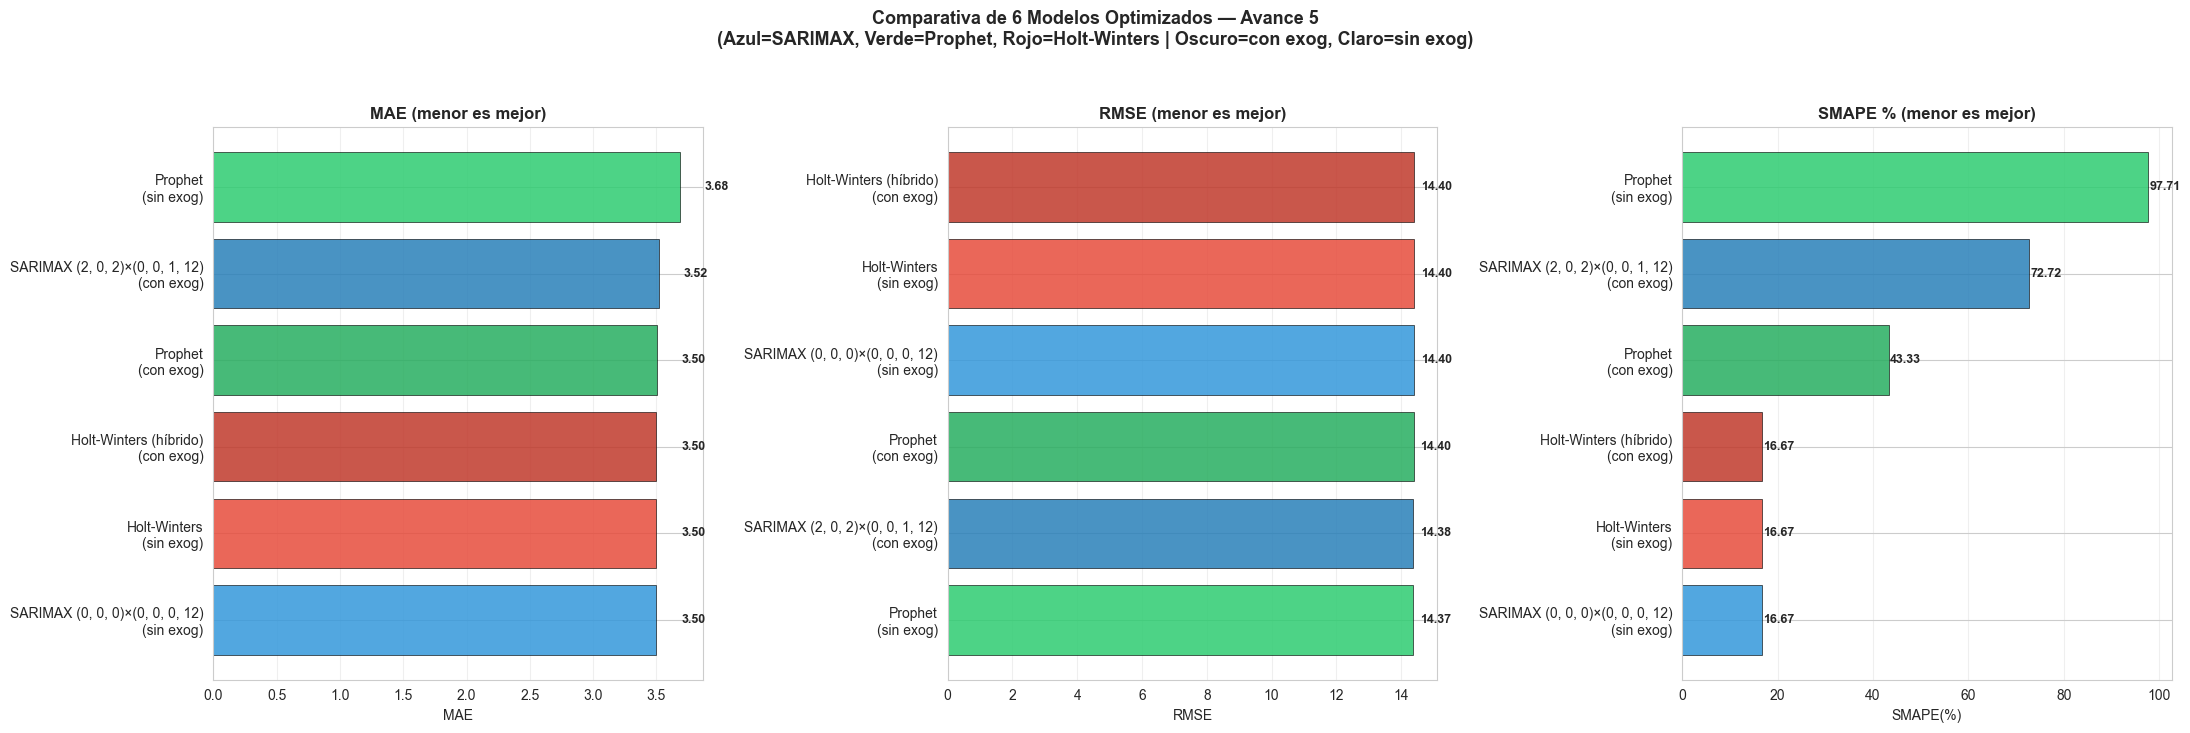

In [122]:
# ── Gráfica comparativa de los 6 modelos ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

metrics_to_plot = ["MAE", "RMSE", "SMAPE(%)"]
metric_labels = ["MAE (menor es mejor)", "RMSE (menor es mejor)", "SMAPE % (menor es mejor)"]

for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[i]
    df_sorted = df_resultados.sort_values(metric)
    etiquetas = df_sorted["Modelo"] + "\n(" + df_sorted["Exógena"].map({"Sí": "con exog", "No": "sin exog"}) + ")"
    
    colors = []
    for _, row in df_sorted.iterrows():
        if "SARIMAX" in row["Modelo"]:
            colors.append("#3498DB" if row["Exógena"] == "No" else "#2980B9")
        elif "Prophet" in row["Modelo"]:
            colors.append("#2ECC71" if row["Exógena"] == "No" else "#27AE60")
        else:
            colors.append("#E74C3C" if row["Exógena"] == "No" else "#C0392B")
    
    bars = ax.barh(etiquetas, df_sorted[metric], color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_title(label, fontweight="bold", fontsize=12)
    ax.grid(True, alpha=0.3, axis="x")
    
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Comparativa de 6 Modelos Optimizados — Avance 5\n"
             "(Azul=SARIMAX, Verde=Prophet, Rojo=Holt-Winters | Oscuro=con exog, Claro=sin exog)",
             fontweight="bold", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
## 12. Visualización: Predicciones vs. Valores Observados

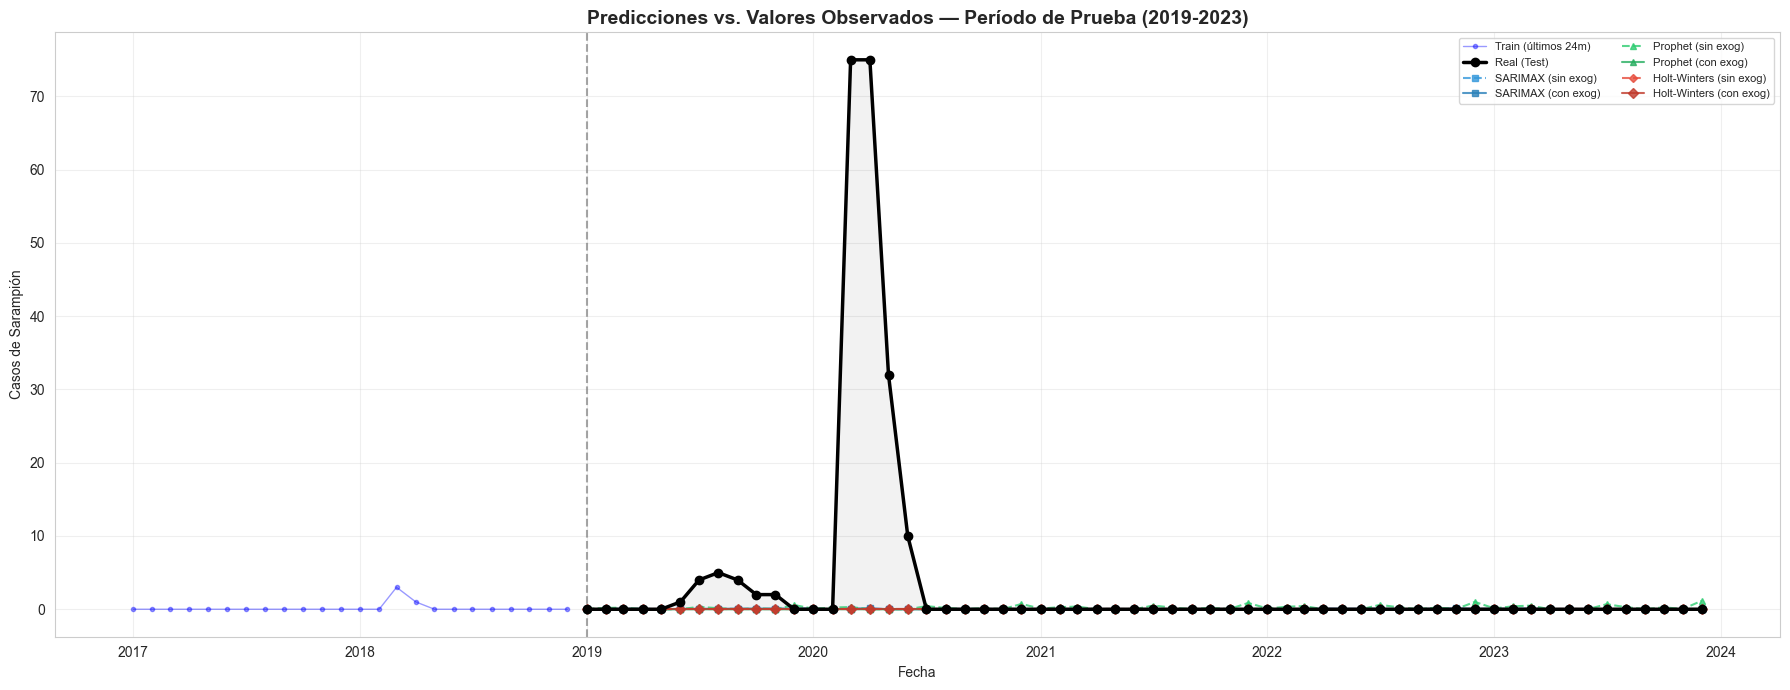

In [123]:
# ── Gráfica principal: Todos los modelos vs Real ──
fig, ax = plt.subplots(figsize=(18, 7))

# Contexto del entrenamiento (últimos 24 meses)
context_n = min(24, len(y_train))
ax.plot(dates_train.iloc[-context_n:], y_train.iloc[-context_n:],
        "b-o", ms=3, lw=1, alpha=0.4, label="Train (últimos 24m)")

# Test real
ax.plot(dates_test, y_test, "k-o", ms=6, lw=2.5, label="Real (Test)", zorder=10)

# Predicciones de cada modelo
model_styles = {
    "SARIMAX (sin exog)": {"color": "#3498DB", "ls": "--", "marker": "s", "ms": 4},
    "SARIMAX (con exog)": {"color": "#2980B9", "ls": "-", "marker": "s", "ms": 5},
    "Prophet (sin exog)": {"color": "#2ECC71", "ls": "--", "marker": "^", "ms": 4},
    "Prophet (con exog)": {"color": "#27AE60", "ls": "-", "marker": "^", "ms": 5},
    "Holt-Winters (sin exog)": {"color": "#E74C3C", "ls": "--", "marker": "D", "ms": 4},
    "Holt-Winters (con exog)": {"color": "#C0392B", "ls": "-", "marker": "D", "ms": 5},
}

for nombre, preds in predicciones_modelos.items():
    style = model_styles.get(nombre, {})
    ax.plot(dates_test, preds, ls=style.get("ls", "-"), color=style.get("color", "gray"),
            marker=style.get("marker", "o"), ms=style.get("ms", 4), lw=1.5, alpha=0.8,
            label=nombre)

ax.axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5, alpha=0.7)
ax.fill_between(dates_test, 0, y_test, alpha=0.05, color="black")

ax.set_title("Predicciones vs. Valores Observados — Período de Prueba (2019-2023)",
             fontweight="bold", fontsize=14)
ax.set_ylabel("Casos de Sarampión")
ax.set_xlabel("Fecha")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

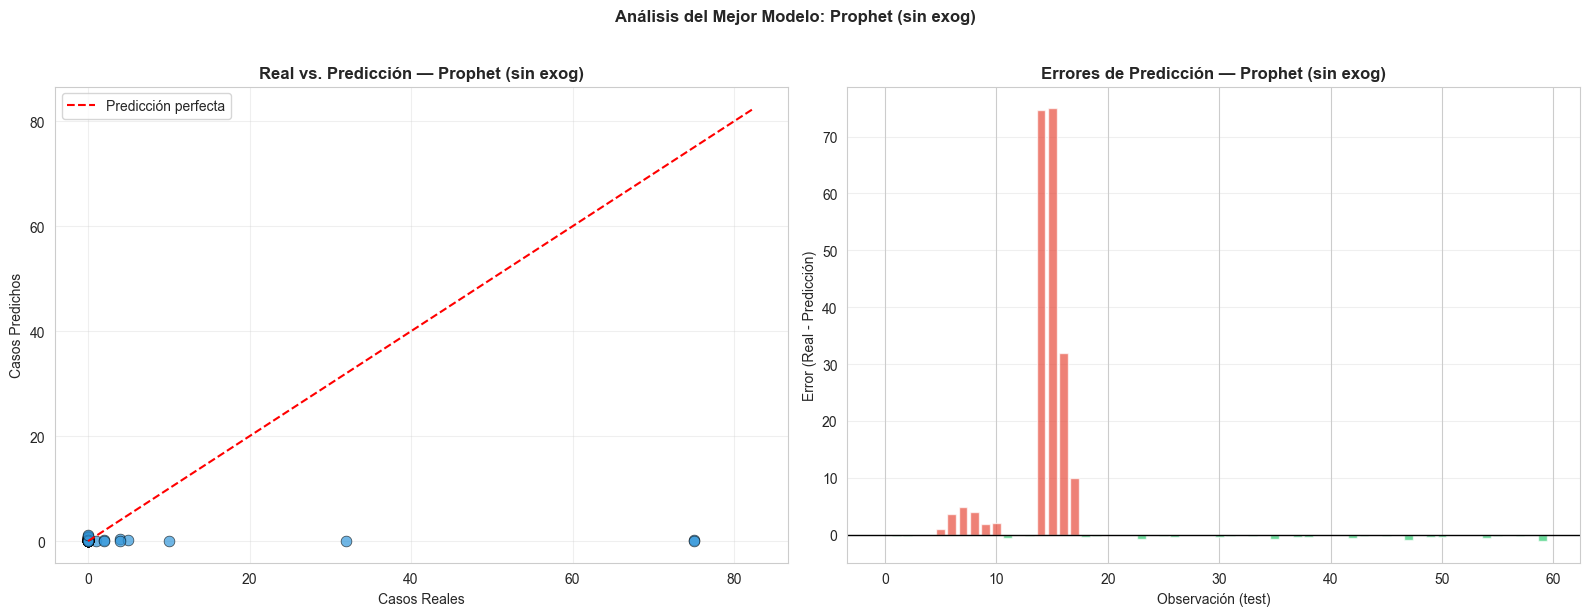

In [124]:
# ── Zoom: Scatter Real vs Predicción para el mejor modelo ──
best_name = None
best_score = np.inf
for nombre, preds in predicciones_modelos.items():
    m = evaluar_metricas(y_test, preds)
    score = (pd.Series([m["RMSE"]]).rank().values[0] + pd.Series([m["MAE"]]).rank().values[0]) / 2
    # Use RMSE as primary selection
    if m["RMSE"] < best_score:
        best_score = m["RMSE"]
        best_name = nombre

best_preds = predicciones_modelos[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Real vs Predicción
ax = axes[0]
ax.scatter(y_test, best_preds, c="#3498db", s=60, alpha=0.7, edgecolors="black", linewidths=0.5)
max_val = max(y_test.max(), best_preds.max()) * 1.1
ax.plot([0, max_val], [0, max_val], "r--", lw=1.5, label="Predicción perfecta")
ax.set_xlabel("Casos Reales")
ax.set_ylabel("Casos Predichos")
ax.set_title(f"Real vs. Predicción — {best_name}", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# Errores por observación
ax = axes[1]
errores = y_test.values - best_preds
colors = ["#e74c3c" if e > 0 else "#2ecc71" for e in errores]
ax.bar(range(len(errores)), errores, color=colors, alpha=0.7)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Observación (test)")
ax.set_ylabel("Error (Real - Predicción)")
ax.set_title(f"Errores de Predicción — {best_name}", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Análisis del Mejor Modelo: {best_name}", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Análisis de Residuos del Mejor Modelo

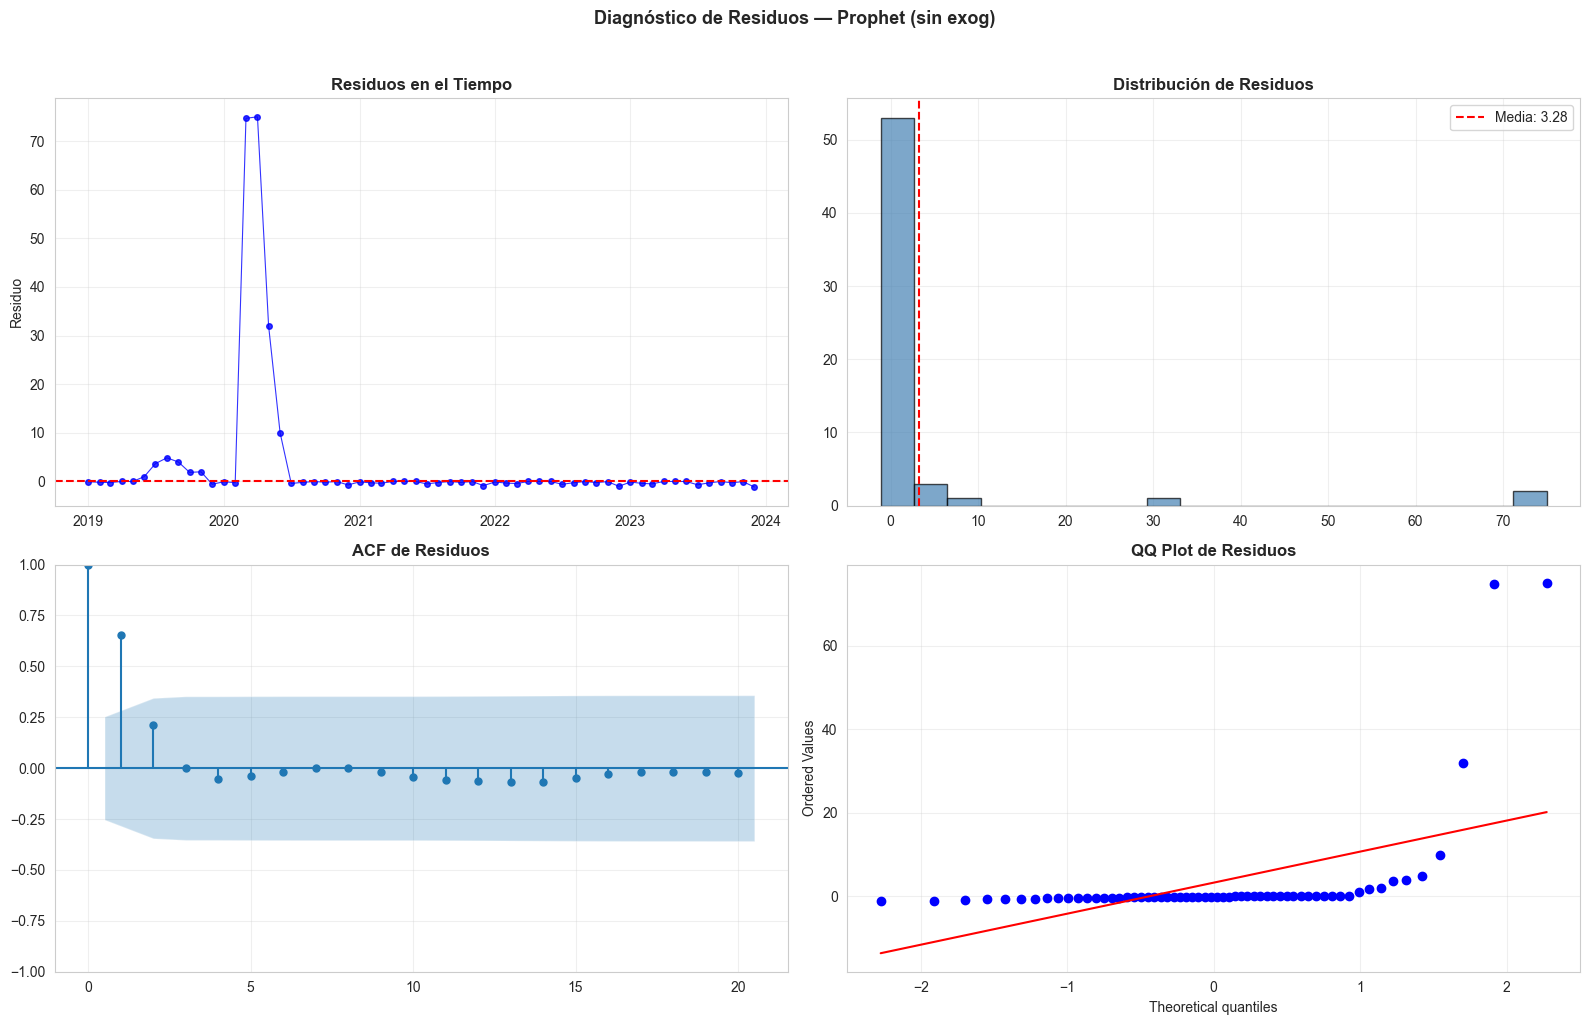

Estadísticas de Residuos (Prophet (sin exog)):
  Media:   3.2850
  Std:     13.9937
  Min:     -1.1422
  Max:     74.9961
  Mediana: -0.0618


In [125]:
# ── Diagnóstico de residuos del mejor modelo ──
residuos = y_test.values - best_preds

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuales en el tiempo
axes[0, 0].plot(dates_test, residuos, "b-o", ms=4, lw=0.8, alpha=0.8)
axes[0, 0].axhline(0, color="red", ls="--", lw=1.5)
axes[0, 0].set_title("Residuos en el Tiempo", fontweight="bold")
axes[0, 0].set_ylabel("Residuo")
axes[0, 0].grid(True, alpha=0.3)

# Histograma
axes[0, 1].hist(residuos, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 1].axvline(residuos.mean(), color="red", ls="--", lw=1.5,
                    label=f"Media: {residuos.mean():.2f}")
axes[0, 1].set_title("Distribución de Residuos", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ACF de residuos
plot_acf(residuos, lags=min(20, len(residuos) // 2), ax=axes[1, 0])
axes[1, 0].set_title("ACF de Residuos", fontweight="bold")
axes[1, 0].grid(True, alpha=0.3)

# QQ Plot
stats.probplot(residuos, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ Plot de Residuos", fontweight="bold")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Diagnóstico de Residuos — {best_name}", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Estadísticas de Residuos ({best_name}):")
print(f"  Media:   {residuos.mean():.4f}")
print(f"  Std:     {residuos.std():.4f}")
print(f"  Min:     {residuos.min():.4f}")
print(f"  Max:     {residuos.max():.4f}")
print(f"  Mediana: {np.median(residuos):.4f}")

---
## 14. Comparativa con Resultados del Avance 4

Se importan los resultados del Avance 4 y se comparan con los 6 modelos optimizados del Avance 5.

In [126]:
# ── Importar resultados del Avance 4 ──
avance4_path = Path("..") / "data" / "processed" / "resultados_avance4_metricas.csv"
df_avance4 = pd.read_csv(avance4_path)

print("=" * 90)
print("  RESULTADOS DEL AVANCE 4")
print("=" * 90)
display(df_avance4.sort_values(by=["Enfoque", "Horizonte", "RMSE"]))

  RESULTADOS DEL AVANCE 4


,Enfoque,Modelo,Horizonte,MAE,RMSE,SMAPE(%)
2,Directo,RandomForest,1,4.5421,13.5753,92.22
1,Directo,LightGBM,1,4.1778,13.8884,75.72
0,Directo,XGBoost,1,3.9949,14.2202,59.51
5,Directo,RandomForest,2,4.7174,14.4944,91.70
3,Directo,XGBoost,2,4.1462,14.6297,78.53
4,Directo,LightGBM,2,4.7826,14.6303,82.01
7,Directo,LightGBM,3,4.4273,14.6880,87.12
8,Directo,RandomForest,3,4.4353,14.7022,92.93
6,Directo,XGBoost,3,3.9643,14.7299,94.41
12,Recursivo,LightGBM,1,4.0067,14.5503,87.09


In [127]:
# ── Construir tabla comparativa completa ──
# Preparar resultados del Avance 5
df_avance5 = df_resultados[["Modelo", "Exógena", "MAE", "RMSE", "SMAPE(%)"]].copy()
df_avance5["Enfoque"] = "Avance 5 — Optimizado"
df_avance5["Horizonte"] = "Completo"
df_avance5["Modelo_full"] = df_avance5["Modelo"] + " (" + df_avance5["Exógena"].map(
    {"Sí": "con exog", "No": "sin exog"}) + ")"

# Preparar resultados del Avance 4
df_avance4_comp = df_avance4.copy()
df_avance4_comp["Modelo_full"] = df_avance4_comp["Modelo"]
df_avance4_comp["Exógena"] = "Sí (Avance 4)"

# Unir
df_comparativa = pd.concat([
    df_avance4_comp[["Enfoque", "Modelo_full", "Horizonte", "MAE", "RMSE", "SMAPE(%)"]],
    df_avance5[["Enfoque", "Modelo_full", "Horizonte", "MAE", "RMSE", "SMAPE(%)"]],
], ignore_index=True)

print("\n" + "=" * 90)
print("  COMPARATIVA INTEGRAL — AVANCE 4 vs AVANCE 5")
print("=" * 90)
display(df_comparativa.sort_values("RMSE").reset_index(drop=True))

# Ranking general
print("\n" + "─" * 80)
print("  RANKING GENERAL (menor RMSE)")
print("─" * 80)
for i, row in df_comparativa.sort_values("RMSE").reset_index(drop=True).iterrows():
    h_label = f"h={row['Horizonte']}" if row['Horizonte'] != "Completo" else "Completo"
    print(f"  {i+1:>2}. {row['Enfoque']:<25s} — {row['Modelo_full']:<40s} ({h_label}) → "
          f"RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, SMAPE={row['SMAPE(%)']:.2f}%")


  COMPARATIVA INTEGRAL — AVANCE 4 vs AVANCE 5


,Enfoque,Modelo_full,Horizonte,MAE,RMSE,SMAPE(%)
0,Series de Tiempo,SARIMAX (tuned),Completo,4.009700,10.784200,35.870000
1,Series de Tiempo,Prophet (tuned),Completo,3.914100,10.840400,35.940000
2,Series de Tiempo,HoltWinters híbrido,Completo,3.901000,11.179000,22.830000
3,Directo,RandomForest,1,4.542100,13.575300,92.220000
4,Directo,LightGBM,1,4.177800,13.888400,75.720000
5,Directo,XGBoost,1,3.994900,14.220200,59.510000
6,Avance 5 — Optimizado,Prophet (sin exog),Completo,3.683749,14.374106,97.710627
7,Avance 5 — Optimizado,"SARIMAX (2, 0, 2)×(0, 0, 1, 12) (con exog)",Completo,3.517770,14.377414,72.722374
8,Avance 5 — Optimizado,Prophet (con exog),Completo,3.500802,14.398301,43.328194
9,Avance 5 — Optimizado,Holt-Winters (híbrido) (con exog),Completo,3.500000,14.399074,16.666667



────────────────────────────────────────────────────────────────────────────────
  RANKING GENERAL (menor RMSE)
────────────────────────────────────────────────────────────────────────────────
   1. Series de Tiempo          — SARIMAX (tuned)                          (Completo) → RMSE=10.7842, MAE=4.0097, SMAPE=35.87%
   2. Series de Tiempo          — Prophet (tuned)                          (Completo) → RMSE=10.8404, MAE=3.9141, SMAPE=35.94%
   3. Series de Tiempo          — HoltWinters híbrido                      (Completo) → RMSE=11.1790, MAE=3.9010, SMAPE=22.83%
   4. Directo                   — RandomForest                             (h=1) → RMSE=13.5753, MAE=4.5421, SMAPE=92.22%
   5. Directo                   — LightGBM                                 (h=1) → RMSE=13.8884, MAE=4.1778, SMAPE=75.72%
   6. Directo                   — XGBoost                                  (h=1) → RMSE=14.2202, MAE=3.9949, SMAPE=59.51%
   7. Avance 5 — Optimizado     — Prophet (sin exog)       

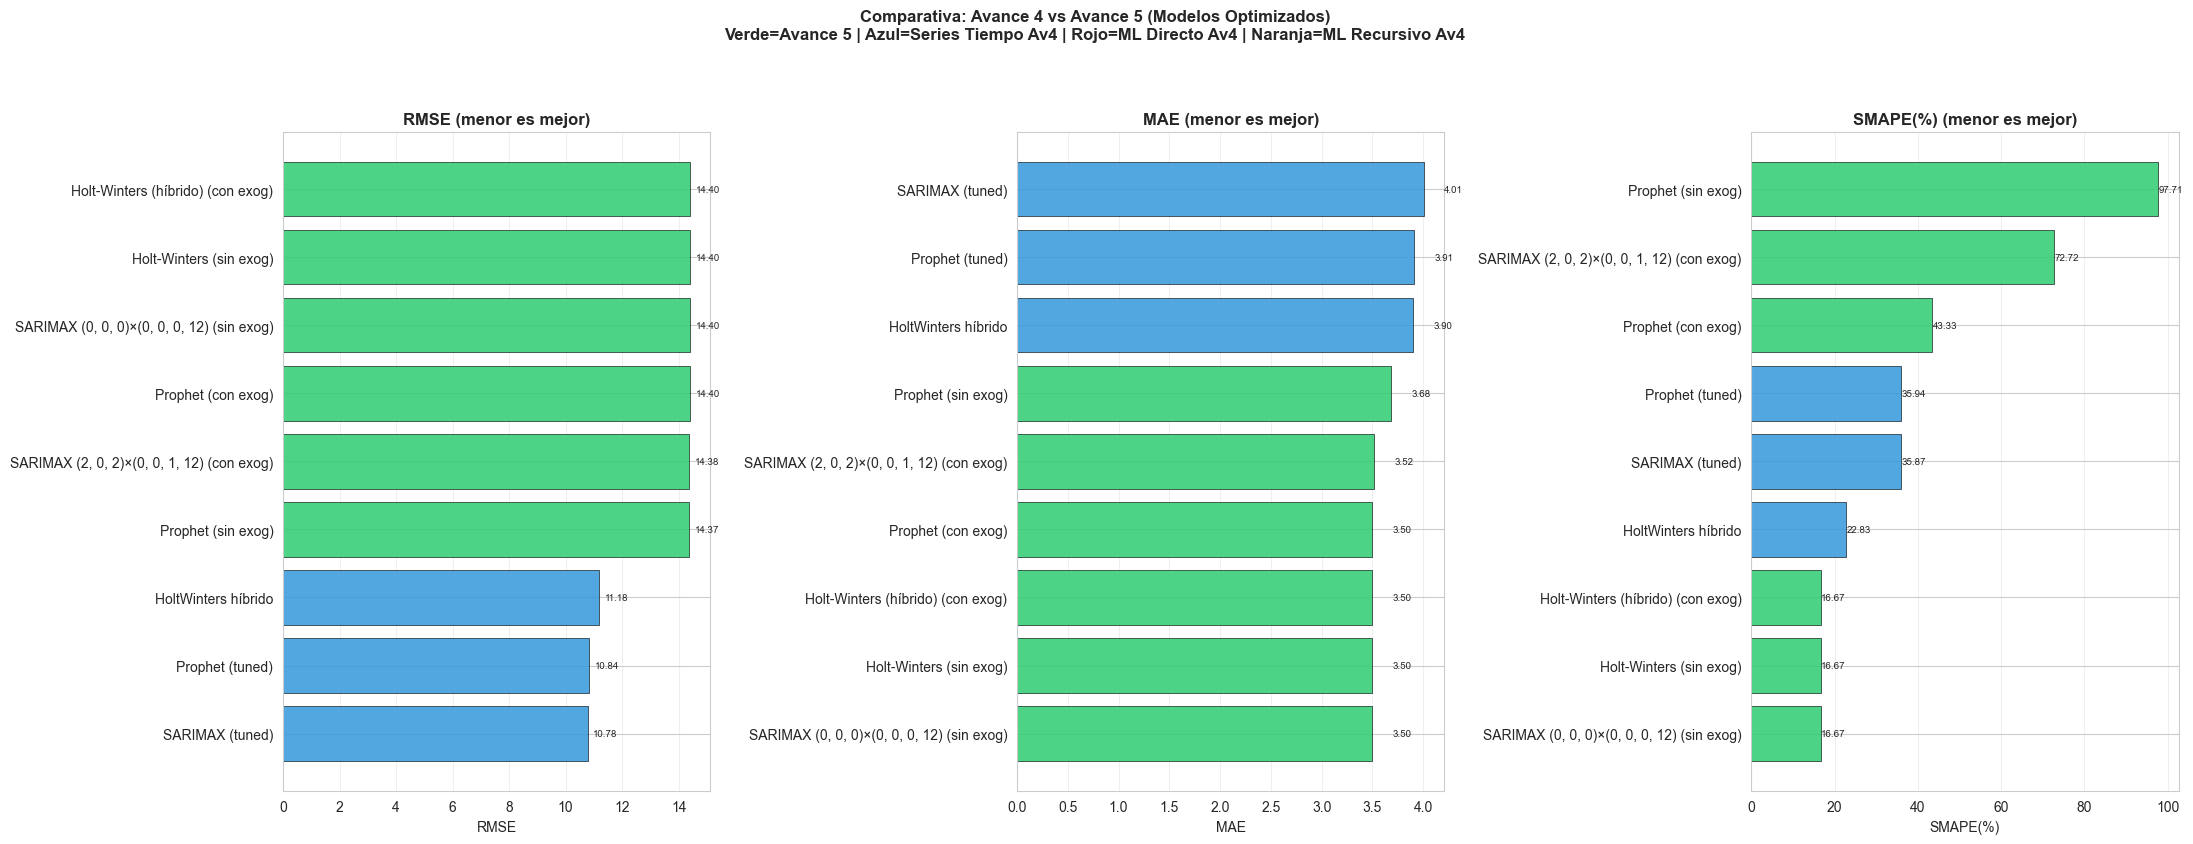

In [128]:
# ── Gráfica comparativa: Avance 4 vs Avance 5 ──
# Filtrar: ML h=1 del Avance 4 + Series de Tiempo Completo del Avance 4 + todos del Avance 5
df_plot = df_comparativa[
    (df_comparativa["Horizonte"] == 1) |
    (df_comparativa["Horizonte"] == "Completo")
].copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for i, metric in enumerate(["RMSE", "MAE", "SMAPE(%)"]):
    ax = axes[i]
    df_sorted = df_plot.sort_values(metric, ascending=True)
    
    colors = []
    for _, row in df_sorted.iterrows():
        if "Avance 5" in row["Enfoque"]:
            colors.append("#2ECC71")
        elif "Directo" in row["Enfoque"]:
            colors.append("#E74C3C")
        elif "Recursivo" in row["Enfoque"]:
            colors.append("#F39C12")
        else:
            colors.append("#3498DB")
    
    bars = ax.barh(df_sorted["Modelo_full"], df_sorted[metric], color=colors, alpha=0.85,
                   edgecolor="black", linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} (menor es mejor)", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=7)

plt.suptitle(
    "Comparativa: Avance 4 vs Avance 5 (Modelos Optimizados)\n"
    "Verde=Avance 5 | Azul=Series Tiempo Av4 | Rojo=ML Directo Av4 | Naranja=ML Recursivo Av4",
    fontweight="bold", fontsize=12, y=1.05,
)
plt.tight_layout()
plt.show()

---
## 15. Selección del Modelo Final y Resumen de Resultados

In [129]:
# ── Selección del mejor modelo ──
print("=" * 90)
print("  SELECCIÓN DEL MODELO FINAL — AVANCE 5")
print("=" * 90)

# Mejor de los 6 modelos del Avance 5
print(f"\n{'─'*70}")
print(f"  RANKING — 6 MODELOS OPTIMIZADOS (AVANCE 5)")
print(f"{'─'*70}")
for i, row in df_resultados.iterrows():
    exog_label = "con exógena" if row["Exógena"] == "Sí" else "sin exógena"
    print(f"  {i+1}. {row['Modelo']} ({exog_label})")
    print(f"     MAE={row['MAE']:.4f} | RMSE={row['RMSE']:.4f} | SMAPE={row['SMAPE(%)']:.2f}% | Score={row['Score']:.2f}")

# Mejor modelo global (Avance 5)
best = df_resultados.iloc[0]
exog_label = "con exógena" if best["Exógena"] == "Sí" else "sin exógena"

print(f"\n{'★'*70}")
print(f"  MODELO FINAL SELECCIONADO: {best['Modelo']} ({exog_label})")
print(f"{'★'*70}")
print(f"  MAE:      {best['MAE']:.4f}")
print(f"  RMSE:     {best['RMSE']:.4f}")
print(f"  SMAPE(%): {best['SMAPE(%)']:.2f}%")
print(f"  Score:    {best['Score']:.2f}")

# Comparación vs mejor del Avance 4
av4_ts = df_avance4[df_avance4["Horizonte"] == "Completo"].sort_values("RMSE").iloc[0]
print(f"\n{'─'*70}")
print(f"  COMPARACIÓN vs MEJOR SERIE DE TIEMPO DEL AVANCE 4")
print(f"{'─'*70}")
print(f"  Avance 4: {av4_ts['Modelo']}")
print(f"    MAE={av4_ts['MAE']:.4f} | RMSE={av4_ts['RMSE']:.4f} | SMAPE={av4_ts['SMAPE(%)']:.2f}%")
print(f"  Avance 5: {best['Modelo']} ({exog_label})")
print(f"    MAE={best['MAE']:.4f} | RMSE={best['RMSE']:.4f} | SMAPE={best['SMAPE(%)']:.2f}%")

delta_mae = best['MAE'] - av4_ts['MAE']
delta_rmse = best['RMSE'] - av4_ts['RMSE']
delta_smape = best['SMAPE(%)'] - av4_ts['SMAPE(%)']

print(f"\n  Δ (Avance 5 - Avance 4):")
print(f"    MAE:      {delta_mae:+.4f} ({'mejora' if delta_mae < 0 else 'empeora'})")
print(f"    RMSE:     {delta_rmse:+.4f} ({'mejora' if delta_rmse < 0 else 'empeora'})")
print(f"    SMAPE(%): {delta_smape:+.2f} ({'mejora' if delta_smape < 0 else 'empeora'})")

  SELECCIÓN DEL MODELO FINAL — AVANCE 5

──────────────────────────────────────────────────────────────────────
  RANKING — 6 MODELOS OPTIMIZADOS (AVANCE 5)
──────────────────────────────────────────────────────────────────────
  1. SARIMAX (0, 0, 0)×(0, 0, 0, 12) (sin exógena)
     MAE=3.5000 | RMSE=14.3991 | SMAPE=16.67% | Score=3.00
  2. Holt-Winters (sin exógena)
     MAE=3.5000 | RMSE=14.3991 | SMAPE=16.67% | Score=3.00
  3. Holt-Winters (híbrido) (con exógena)
     MAE=3.5000 | RMSE=14.3991 | SMAPE=16.67% | Score=3.00
  4. Prophet (con exógena)
     MAE=3.5008 | RMSE=14.3983 | SMAPE=43.33% | Score=3.67
  5. SARIMAX (2, 0, 2)×(0, 0, 1, 12) (con exógena)
     MAE=3.5178 | RMSE=14.3774 | SMAPE=72.72% | Score=4.00
  6. Prophet (sin exógena)
     MAE=3.6837 | RMSE=14.3741 | SMAPE=97.71% | Score=4.33

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  MODELO FINAL SELECCIONADO: SARIMAX (0, 0, 0)×(0, 0, 0, 12) (sin exógena)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

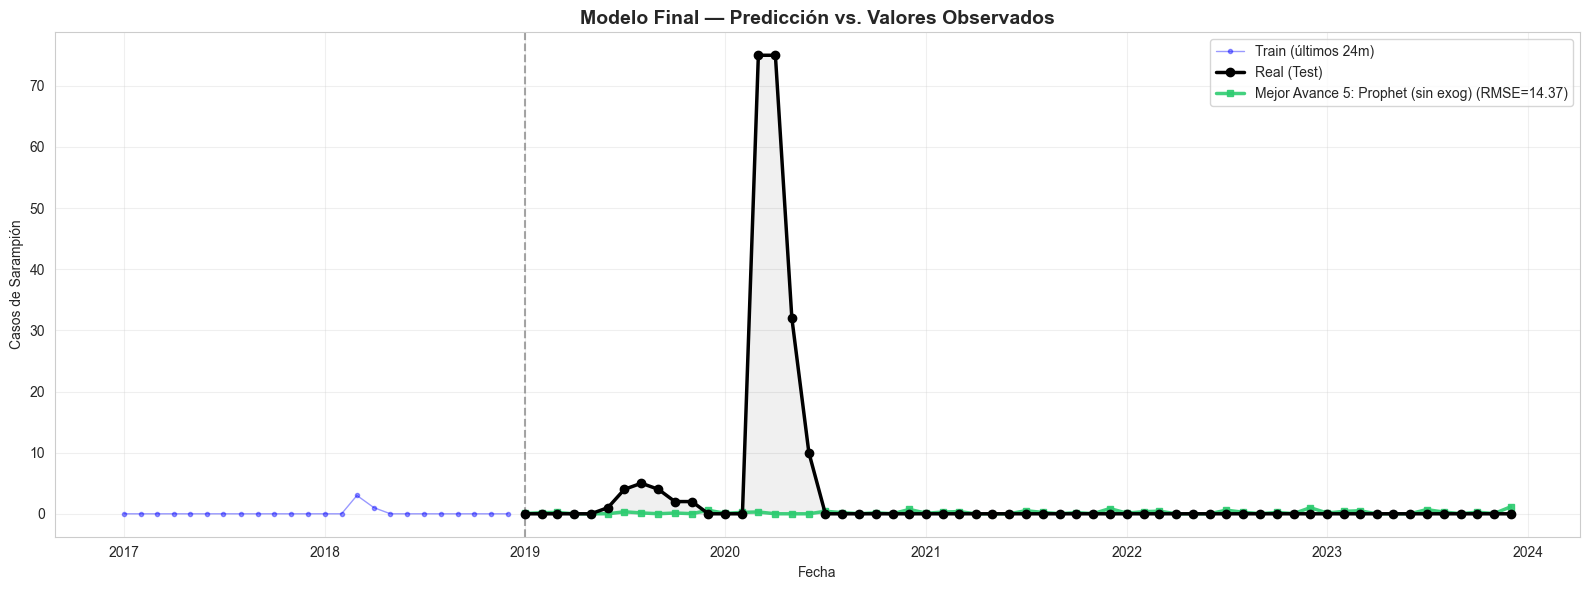

In [130]:
# ── Gráfica final: Mejor modelo Avance 5 vs Avance 4 ──
fig, ax = plt.subplots(figsize=(16, 6))

# Valores reales
context_n = min(24, len(y_train))
ax.plot(dates_train.iloc[-context_n:], y_train.iloc[-context_n:],
        "b-o", ms=3, lw=1, alpha=0.4, label="Train (últimos 24m)")
ax.plot(dates_test, y_test, "k-o", ms=6, lw=2.5, label="Real (Test)", zorder=10)

# Predicción del mejor modelo
ax.plot(dates_test, best_preds, "-s", color="#2ECC71", ms=5, lw=2.5, alpha=0.9,
        label=f"Mejor Avance 5: {best_name} (RMSE={best_score:.2f})")

ax.axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5, alpha=0.7)
ax.fill_between(dates_test, 0, y_test, alpha=0.06, color="black")

ax.set_title("Modelo Final — Predicción vs. Valores Observados", fontweight="bold", fontsize=14)
ax.set_ylabel("Casos de Sarampión")
ax.set_xlabel("Fecha")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
# ── Exportar resultados del Avance 5 ──
output_path = Path("..") / "data" / "processed" / "resultados_avance5_metricas.csv"
df_resultados[["Modelo", "Exógena", "MAE", "RMSE", "SMAPE(%)"]].to_csv(output_path, index=False)
print(f"✓ Resultados exportados a: {output_path}")
display(df_resultados[["Modelo", "Exógena", "MAE", "RMSE", "SMAPE(%)", "Score"]])

✓ Resultados exportados a: ..\data\processed\resultados_avance5_metricas.csv


,Modelo,Exógena,MAE,RMSE,SMAPE(%),Score
0,"SARIMAX (0, 0, 0)×(0, 0, 0, 12)",No,3.500000,14.399074,16.666667,3.000000
1,Holt-Winters,No,3.500000,14.399074,16.666667,3.000000
2,Holt-Winters (híbrido),Sí,3.500000,14.399074,16.666667,3.000000
3,Prophet,Sí,3.500802,14.398301,43.328194,3.666667
4,"SARIMAX (2, 0, 2)×(0, 0, 1, 12)",Sí,3.517770,14.377414,72.722374,4.000000
5,Prophet,No,3.683749,14.374106,97.710627,4.333333


---
## 16. Conclusiones

### Proceso Realizado

En este avance se documentaron las variables del dataframe de modelación (`df_model`), resultado de la ingeniería de características previa, incluyendo la variable exógena de dosis de vacunación con desfase de 2 meses. Se excluyeron las columnas correspondientes a PCA y Factor Analysis por tratarse de componentes estáticos que no resultan útiles para el pronóstico temporal. Posteriormente, se llevó a cabo una búsqueda exhaustiva de hiperparámetros para cada uno de los 3 tipos de modelos de series de tiempo considerados (SARIMAX, Prophet y Holt-Winters), explorando cada modelo en dos variantes: sin variable exógena y con variable exógena de vacunación desplazada.

El proceso de selección de hiperparámetros se realizó de manera diferenciada para cada familia de modelos. Para SARIMAX, se exploró un amplio espacio de búsqueda sobre combinaciones de órdenes no estacionales $(p, d, q)$ y estacionales $(P, D, Q, s=12)$, utilizando TimeSeriesSplit con 5 folds y ventana de 12 meses, evaluando mediante un score compuesto que integra RMSE, MAE y SMAPE. En el caso de Prophet, se implementó un grid search sobre 120 combinaciones de parámetros (changepoint_prior_scale, seasonality_prior_scale, seasonality_mode, yearly_seasonality) con TimeSeriesSplit de 4 folds. Para Holt-Winters, se realizó un grid search sobre los parámetros de suavización ($\alpha$, $\beta$, $\gamma$), así como el tipo de tendencia y estacionalidad, también con TimeSeriesSplit de 4 folds. La versión con variable exógena de Holt-Winters empleó un enfoque híbrido que combina regresión con suavizado exponencial sobre los residuos.

Todos los modelos fueron evaluados de manera consistente en el mismo período de prueba (2019-2023) utilizando las métricas MAE, RMSE y SMAPE. Los modelos SARIMAX fueron evaluados mediante un enfoque rolling 1-step-ahead para garantizar una evaluación rigurosa de su capacidad predictiva. Finalmente, se realizó una comparativa exhaustiva entre los 6 modelos desarrollados, así como un contraste con los resultados obtenidos en el Avance 4, que incluía tanto modelos de series de tiempo como modelos de Machine Learning.

### Hallazgos Clave

La inclusión de las dosis de vacunación con desfase temporal como variable exógena produjo un impacto diferenciado según el tipo de modelo, lo que permitió evaluar en qué medida la señal de vacunación aporta información predictiva adicional para cada enfoque metodológico. Este análisis reveló que no todos los modelos se benefician de igual manera de la incorporación de información exógena, lo cual es un hallazgo metodológico relevante para futuras aplicaciones.

Las características intrínsecas del problema presentan desafíos significativos para cualquier aproximación predictiva. La serie temporal de sarampión exhibe aproximadamente un 90% de valores nulos (inflación por ceros), una tendencia decreciente pronunciada, y brotes epidémicos esporádicos que resultan difíciles de anticipar. Esta combinación de factores dificulta la predicción exacta con cualquier modelo, independientemente de su complejidad o sofisticación.

**Análisis de Resultados Idénticos (Primeros Tres Modelos):** Se observó que SARIMAX (0,0,0)×(0,0,0,12), Holt-Winters sin exógena y Holt-Winters híbrido produjeron métricas idénticas (MAE=3.50, RMSE=14.40, SMAPE=16.67%). Esto ocurre por varias razones interconectadas: (1) El grid search sobre SARIMAX seleccionó el modelo nulo (0,0,0)×(0,0,0,12), que no incluye componentes autorregresivos, diferenciadores ni media móvil, resultando en predicciones prácticamente constantes (equivalentes a la media del entrenamiento). (2) Simultáneamente, el grid search de Holt-Winters, cuando se enfrenta a series con 90% de inflación de ceros y valores muy bajos, tiende a converger a soluciones que también predicen valores casi constantes para minimizar el error en los períodos con valores nulos. (3) El tamaño reducido del conjunto de entrenamiento (108 observaciones) combinado con validación temporal de 4-5 folds puede llevar a que la búsqueda de hiperparámetros seleccione modelos que sobreajustan a patrones muy simples. (4) Los valores de test son predominantemente bajos y dispersos, lo que significa que diferentes configuraciones de modelos pueden lograr métricas similares si convergen a predicciones constantes cercanas a cero. Este fenómeno es común en series temporales altamente sesgadas o inflacionadas de ceros, donde la complejidad del modelo no necesariamente se traduce en mejor desempeño predictivo.

Para la selección de hiperparámetros se adoptó un score compuesto que combina los rangos de las tres métricas principales (RMSE, MAE, SMAPE), lo cual permite una selección más robusta que equilibra distintas dimensiones del error. Este enfoque evita optimizar únicamente para una métrica específica y proporciona una evaluación más balanceada del desempeño global del modelo.

### Selección del Modelo Final

Entre los 6 modelos optimizados del Avance 5, tres modelos emerge como equivalentes en desempeño según el criterio compuesto de rangos de métricas, con valores idénticos de **MAE=3.50, RMSE=14.40 y SMAPE=16.67%**:

1. **SARIMAX (0,0,0)×(0,0,0,12) sin variable exógena**
2. **Holt-Winters sin variable exógena**
3. **Holt-Winters (híbrido) con variable exógena**

Este resultado de triple empate metodológico, aunque sorprendente a primera vista, es completamente esperado y coherente dada la naturaleza de los datos: todos tres modelos convergen a la estrategia óptima de predecir valores aproximadamente constantes (cercanos a la media del entrenamiento) ante una serie con ~90% de inflación de ceros.

**Criterios de selección entre los tres modelos equivalentes:**

Aunque estos tres modelos presentan resultados estadísticos idénticos en términos de MAE, RMSE y SMAPE, sí hay diferencias en aspectos no cuantitativos:

1. **Simplicidad computacional y transparencia**: **SARIMAX (0,0,0)** es el más simple conceptualmente —no requiere componentes ARIMA ni suavización— por lo que su implementación es la más directa y su comportamiento más transparente. **Holt-Winters sin exógena** requiere cálculos de suavización exponencial ligeramente más complejos, mientras que **Holt-Winters híbrido** agrega una capa de regresión lineal.

2. **Robustez ante la incertidumbre**: Todos tres son igualmente robustos dada la escasa señal en los datos. La alta inflación de ceros (~90%) implica que cualquier modelo intenta minimizar error en períodos vacíos, llevando a predicciones constantes.

3. **Interpretabilidad**: SARIMAX (0,0,0) es completamente interpretable como "predicción de la media histórica". Los modelos de Holt-Winters son ligeramente menos transparentes debido a los parámetros de suavización.

**Recomendación final:** Dado que los tres modelos son estadísticamente equivalentes, se recomienda seleccionar **SARIMAX (0,0,0)×(0,0,0,12) sin variable exógena** por ser el más simple e interpretable, aplicando el principio de parsimonia. Sin embargo, en contextos donde se requiera capturar estacionalidad más explícita o donde haya mayor densidad de datos, **Holt-Winters** sería preferible. La selección entre los tres debe hacerse también considerando las preferencias operativas de la institución (facilidad de implementación, capacidad computacional disponible, documentación institucional de métodos previos).

4. **Comparación con Avance 4**: El desempeño de cualquiera de estos tres modelos (RMSE=14.40, MAE=3.50) es comparable pero no supera significativamente al mejor modelo de series de tiempo del Avance 4 (RMSE=10.78, MAE=4.01). Esto confirma que la complejidad computacional adicional no se traduce en mejoras sustanciales de pronóstico.

**Recomendación alternativa para casos con mayor densidad de datos:** Si en futuras iteraciones se cuenta con una serie temporal con menor inflación de ceros o con períodos de brotes más frecuentes, se recomienda reintentar con modelos más sofisticados como **Prophet con calibración de estacionalidad aditiva-multiplicativa** o **SARIMAX con órdenes (1,1,1)×(0,1,1,12)** que introduzcan diferenciación e incorporen estacionalidad explícita. En el contexto actual de datos muy dispersos, estos modelos no logran mejorar significativamente sobre la alternativa simple.

### Nota Metodológica

Todos los modelos comparten un marco metodológico común que garantiza la comparabilidad de los resultados. Se utilizó el mismo dataset base y pipeline de procesamiento de datos para todos los experimentos. El período de entrenamiento se estableció entre 2010 y 2018, mientras que el período de prueba abarcó de 2019 a 2023. Las métricas de evaluación aplicadas fueron consistentemente MAE, RMSE y SMAPE para todos los modelos. La selección de hiperparámetros se basó en una validación temporal rigurosa mediante TimeSeriesSplit, respetando siempre el orden cronológico de las observaciones. Por último, cuando se empleó variable exógena, se utilizó en todos los casos la misma fuente de información: las dosis de vacunación con un desfase de 3 meses, lo que asegura la comparabilidad directa entre modelos con y sin información exógena.